
<span style="color: pink; font-size:32px; font-weight:bold; text-align:center; ">
     Proyecto entregable empresa aliada 4
</span>


- # Crear una nueva base de datos en SSMS para almacenar todas las tablas de datos proporcionadas.

- # Definir la estructura de las tablas necesarias para los conjuntos de datos (DIM_CATEGORY, DIM_PRODUCT, DIM_SEGMENT, DIM_CALENDAR, FACT_SALES).

-  # Importar los datos en cada tabla utilizando las funciones de importación.

- # Ejecutar uniones entre las tablas para combinar la información y obtener insights clave sobre las ventas por categoría, región y periodo de tiempo.

### Importar librerías 

In [3]:
import pandas as pd 
import sqlite3

### Cargar datos y crear conexión 

In [5]:
## Crear conección y db
coneccion = sqlite3.connect("EmpresaVentas.db")
# Crear cursor
cur= coneccion.cursor()

In [9]:
# Cargar dimensiones categoricas con pandas  
dim_category = pd.read_csv("DIM_CATEGORY.csv")

# Limpieza ligera opcional (espacios, saltos de línea)
dim_category["CATEGORY"] = dim_category["CATEGORY"].str.strip()

# Mostrar los primeros registros 
dim_category.head()


,ID_CATEGORY,CATEGORY
0,1,FABRIC TREATMENT and SANIT
1,2,AIR CARE
2,3,LAVAVAJILLAS
3,4,MEGA SUPERFICIES
4,5,LAVATORY CARE & BRC


#### Mandarlo a SQLite

In [11]:
dim_category.to_sql("DIM_CATEGORY", coneccion, if_exists="replace",   index= False )
                #    titulo-tabla   SQLBrowser  reemplazala si exist    no copiar el indice de pandas

5

### Agregar los archivos restantes de csv 


In [13]:
fact_sales=pd.read_csv("FACT_SALES (1).csv")
fact_sales.head()

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5
1,34-22,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5
2,34-22,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5
3,34-22,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5
4,34-22,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5


In [15]:
# Crear en SQL 
fact_sales.to_sql("FACT_SALES",coneccion,if_exists="replace", index=False)

122002

### Agregar los archivos restantes 


In [17]:
## Cargar las 3 tablas restantes en excel 
dim_product = pd.read_excel("DIM_PRODUCT (1).xlsx")
print(dim_product.head(), "\n ====================================")
dim_segment = pd.read_excel("DIM_SEGMENT (1).xlsx")
print(dim_segment.head(), "\n=====================================")
dim_calendar = pd.read_excel("DIM_CALENDAR (4).xlsx")
print(dim_calendar.head())
## Conecciónes restantes a SQLBrowser
dim_product.to_sql("DIM_PRODUCT", coneccion, if_exists="replace", index=False)
dim_segment.to_sql("DIM_SEGMENT", coneccion, if_exists="replace", index=False)
dim_calendar.to_sql("DIM_CALENDAR", coneccion, if_exists="replace", index=False)

  MANUFACTURER     BRAND           ITEM  \
0   INDS. ALEN  CLORALEX  0000075000592   
1   INDS. ALEN  CLORALEX  0000075000608   
2   INDS. ALEN  CLORALEX  0000075000615   
3   INDS. ALEN  CLORALEX  0000075000622   
4   INDS. ALEN  CLORALEX  0000075000639   

                                    ITEM_DESCRIPTION  CATEGORY   FORMAT  \
0  CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...         1  LIQUIDO   
1  CLORALEX EL RENDIDOR BOT.PLAST. 500ML NAL. 000...         1  LIQUIDO   
2  CLORALEX EL RENDIDOR BOT.PLAST. 950ML NAL. 000...         1  LIQUIDO   
3  CLORALEX EL RENDIDOR BOT.PLAST. 2000ML NAL 000...         1  LIQUIDO   
4  CLORALEX EL RENDIDOR BOT.PLAST. 3750ML NAL 000...         1  LIQUIDO   

   ATTR1  ATTR2        ATTR3  
0  CLORO  CLORO  NO DEFINIDO  
1  CLORO  CLORO  NO DEFINIDO  
2  CLORO  CLORO  NO DEFINIDO  
3  CLORO  CLORO  NO DEFINIDO  
4  CLORO  CLORO  NO DEFINIDO   
   CATEGORY  ATTR1  ATTR2      ATTR3   FORMAT SEGMENT
0         1  CLORO  CLORO    BAMBINO  LIQUIDO  BL

156

# Capturas de pantalla corroborrando los datos

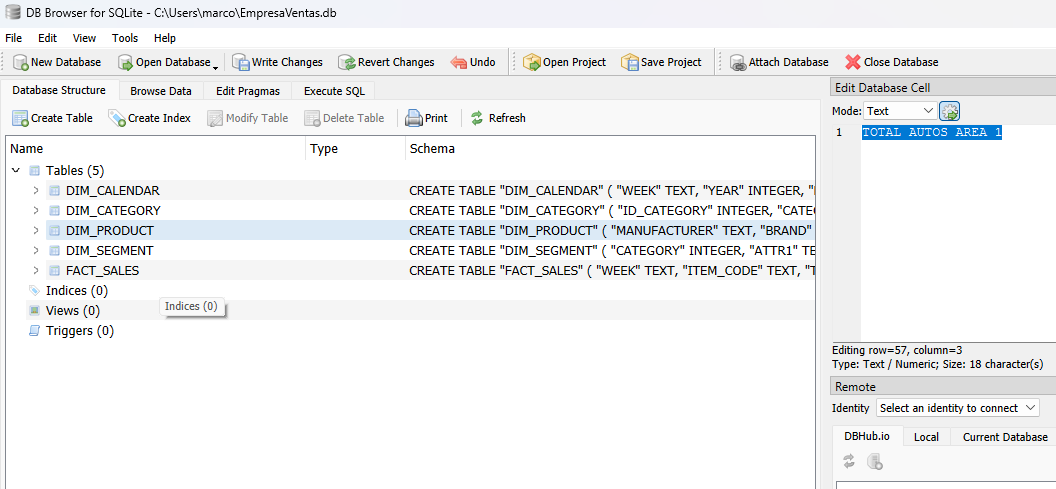

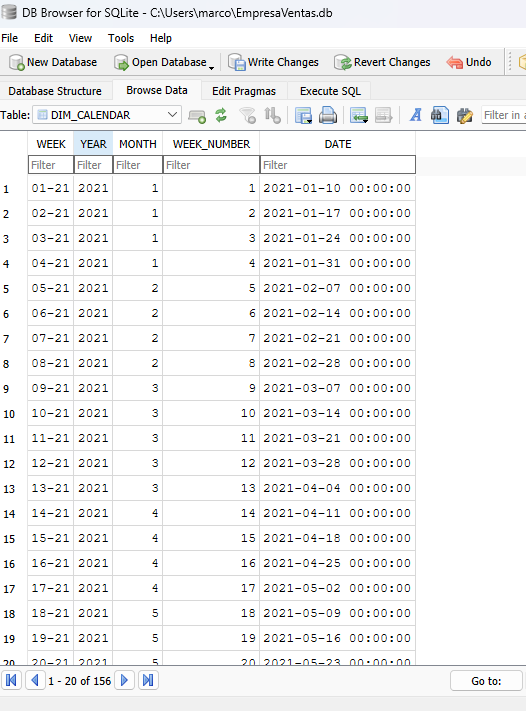

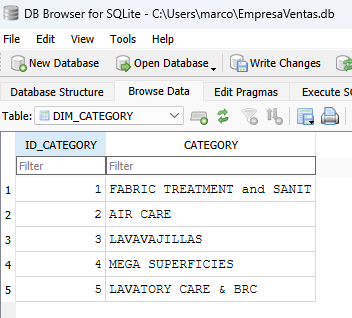

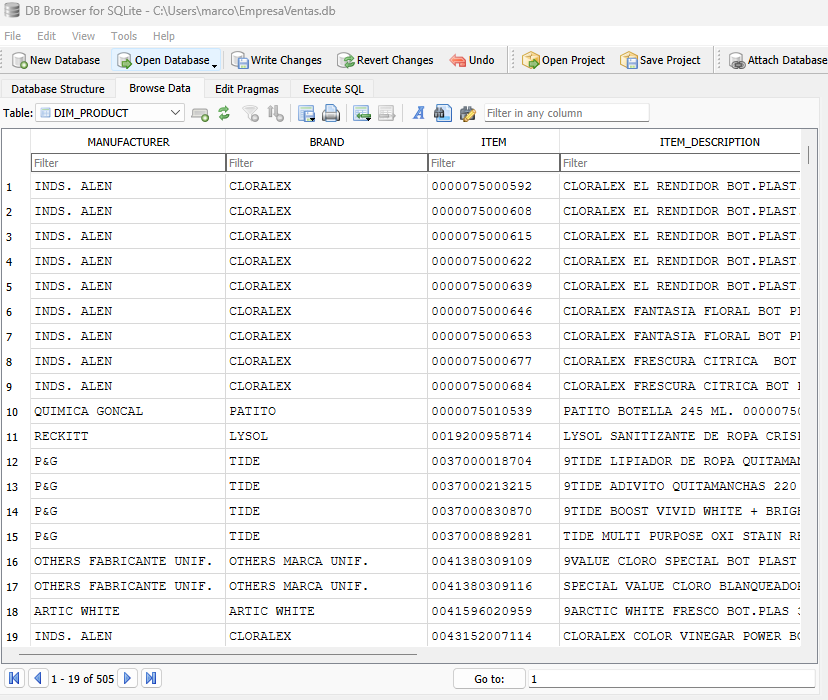

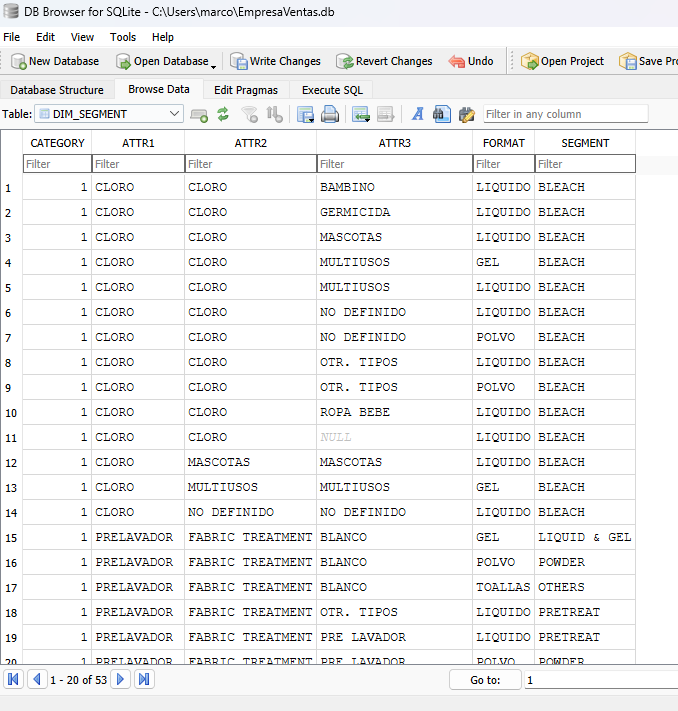

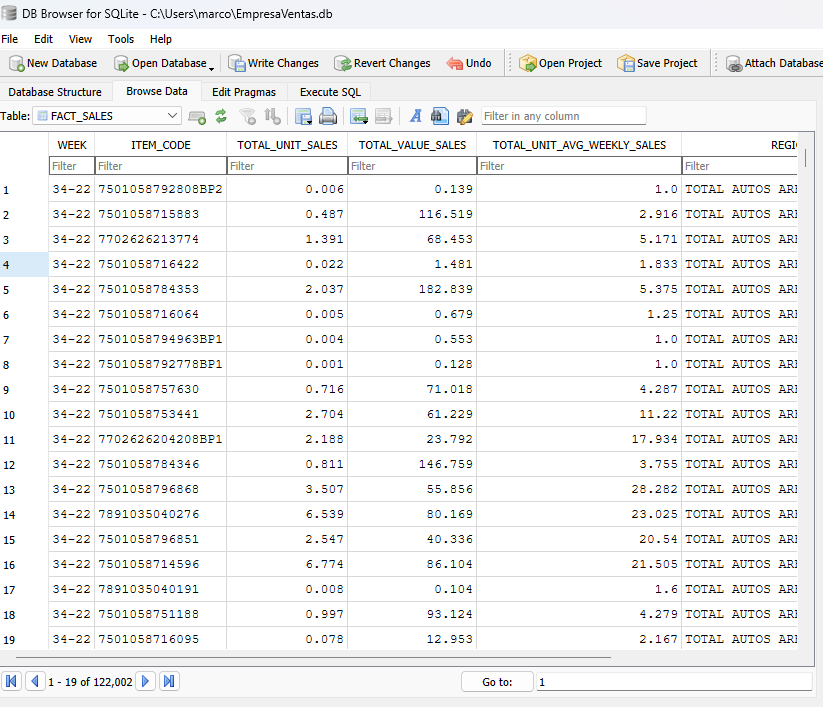

# Uniones de las tablas | Para saber como hacer las relaciones

### * FACT_SALES <----> DIM_CALENDAR 
<span style="color:purple; font-weight:bold;">
    Se puede unir con la columna WEEK
</span>
 
### * DIM_PRODUCT <----> DIM_CATEGORY
 Unir CATEGORY con ID_CATEGORY 


### * DIM_PRODUCT <----> DIM_SEGMENT 


#### Las dos tablas comparten estas columnas:
1. CATEGORY
2. ATTR1
3. ATTR2
4. ATTR3
5. FORMAT
   
En DIM_SEGMENT esa combinación te da un SEGMENT
DIM_PRODUCT.(CATEGORY, ATTR1, ATTR2, ATTR3, FORMAT) ----> DIM_SEGMENT.(CATEGORY, ATTR1, ATTR2, ATTR3, FORMAT)


### * FACT_SALES <------> DIM_PRODUCT


####   FACT_SALES(ITEM_CODE) viene a veces con sufijo:
 1.- 7501058792808BP2, 7501058794963BP1, etc.
####   En DIM_PRODUCT(ITEM) viene el código base:
 2.- 7501058792808, 7702626213774, etc.

 Si le quitas el BP1, BP2, etc. al ITEM_CODE, queda el mismo código que DIM_PRODUCT.ITEM.

In [19]:
# 4) --Normalizar ITEM en DIM_PRODUCT (quitar ceros a la izquierda)
dim_product["ITEM_NORM"] = dim_product["ITEM"].astype(str).str.lstrip("0")
# 4) --Normalizar ITEM_CODE en FACT_SALES (quitar BP1/BP2)
fact_sales["ITEM_NORM"] = (
    fact_sales["ITEM_CODE"]
    .astype(str)
    .str.replace("BP1", "", regex=False)
    .str.replace("BP2", "", regex=False)
)

# 4) Volver a guardar las tablas en SQLite
dim_product.to_sql("DIM_PRODUCT", coneccion, if_exists="replace", index=False)
fact_sales.to_sql("FACT_SALES", coneccion, if_exists="replace", index=False)

122002

# INSIGTHS 

## VENTAS POR CATEGORIA

In [46]:
cur.execute("SELECT DISTINCT CATEGORY FROM DIM_PRODUCT;")
resultado = cur.fetchall()
resultado

[(1,)]

In [48]:
## Como solo tenemos una categoría esperamos solamente una fila con la suma de ventas totales

In [34]:
query_ventas_categoria = """
SELECT 
    c.CATEGORY AS NombreCategoria,
    SUM(fs.TOTAL_VALUE_SALES) AS VentasTotales
FROM FACT_SALES fs
JOIN DIM_PRODUCT p
    ON fs.ITEM_NORM = p.ITEM_NORM
JOIN DIM_CATEGORY c
    ON p.CATEGORY = c.ID_CATEGORY
GROUP BY c.CATEGORY
ORDER BY VentasTotales DESC;
"""

df_ventas_categoria = pd.read_sql_query(query_ventas_categoria, coneccion)
df_ventas_categoria


,NombreCategoria,VentasTotales
0,FABRIC TREATMENT and SANIT,7849676.516


## Ventas totales por REGIÓN  

In [58]:
query_ventas_region ="""
    SELECT 
        fs.REGION,
        SUM(fs.TOTAL_VALUE_SALES) AS VentasTotales
    FROM FACT_SALES fs
    GROUP BY fs.REGION
    ORDER BY VentasTotales DESC;
"""
df_ventas_region = pd.read_sql_query(query_ventas_region, coneccion)
df_ventas_region

,REGION,VentasTotales
0,TOTAL AUTOS SCANNING MEXICO,5521429.320
1,TOTAL AUTOS AREA 2,1188796.150
2,TOTAL AUTOS AREA 5,1153335.538
3,TOTAL AUTOS AREA 6,983957.571
4,TOTAL AUTOS AREA 3,803655.337
5,TOTAL AUTOS AREA 1,714249.979
6,TOTAL AUTOS AREA 4,677435.998


In [90]:
query_ventas_region_fecha = """
SELECT 
    cal.YEAR,
    cal.MONTH,
    fs.REGION,
    SUM(fs.TOTAL_VALUE_SALES) AS VentasTotales
FROM FACT_SALES fs
JOIN DIM_CALENDAR cal
    ON fs.WEEK = cal.WEEK
GROUP BY cal.YEAR, cal.MONTH, fs.REGION
ORDER BY cal.YEAR, cal.MONTH, fs.REGION;
"""

df_ventas_region_fecha = pd.read_sql_query(query_ventas_region_fecha, coneccion)
df_ventas_region_fecha


,YEAR,MONTH,REGION,VentasTotales
0,2022,1,TOTAL AUTOS AREA 1,42964.722
1,2022,1,TOTAL AUTOS AREA 2,68856.509
2,2022,1,TOTAL AUTOS AREA 3,49252.452
3,2022,1,TOTAL AUTOS AREA 4,43190.806
4,2022,1,TOTAL AUTOS AREA 5,74138.338
...,...,...,...,...
128,2023,7,TOTAL AUTOS AREA 3,35442.417
129,2023,7,TOTAL AUTOS AREA 4,29178.904
130,2023,7,TOTAL AUTOS AREA 5,48228.236
131,2023,7,TOTAL AUTOS AREA 6,41436.356


In [98]:
## Como el insight de arriba es más grande creo que vale la pena agregarlo como tabla 
df_ventas_region_fecha.to_sql("VentasPorRegion_FECHA", coneccion, if_exists="replace", index=False)

133

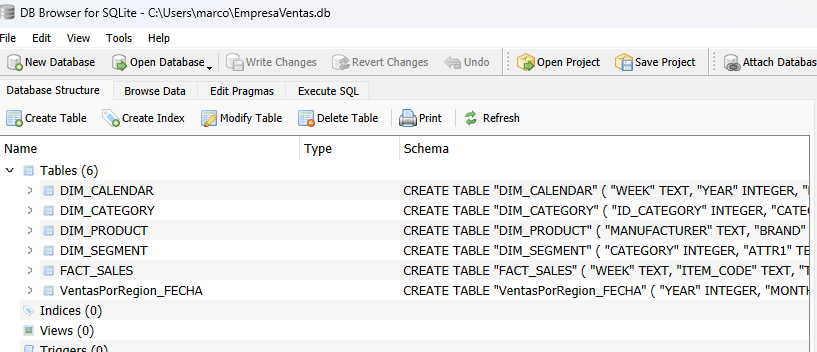

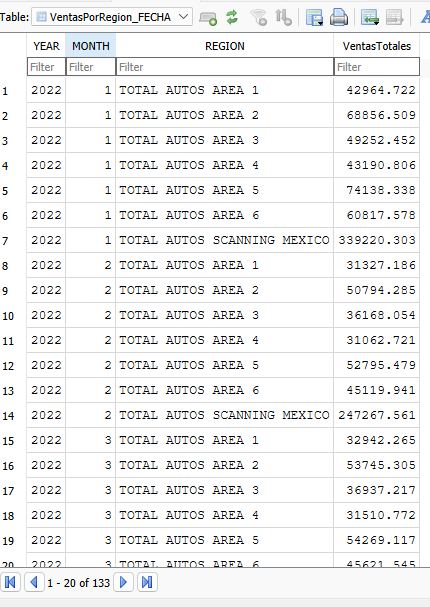

# Distribución por región y periodo de tiempo
1.- A partir de la tabla VENTAS_POR_REGION_FECHA se observa la evolución del valor total de ventas por región y mes. Para cada combinación de YEAR, MONTH y REGION se obtiene el indicador VentasTotales, lo que permite identificar de forma clara qué áreas tienen mayor participación en cada periodo.

Ejemplo concreto (enero 2022)
-- Por ejemplo, en enero de 2022 (YEAR = 2022, MONTH = 1) se aprecia que la región “TOTAL AUTOS AREA 5” presenta un valor de ventas superior (≈ 74,138) en comparación con otras áreas como “TOTAL AUTOS AREA 1” (≈ 42,965) y “TOTAL AUTOS AREA 4” (≈ 43,191). Esto sugiere que el Área 5 concentra una mayor actividad comercial dentro de ese periodo.

2.- A lo largo de los meses esa sigue siendo una constante, donde el Área 5 suele generar más valor de ventas a comparación de las demás regiones 



# Región consolidada a nivel México

 En los registros más recientes (por ejemplo, julio de 2023), la región “TOTAL AUTOS SCANNING MEXICO” alcanza valores agregados de ventas considerablemente mayores (≈ 236,563) que los de cada área individual (por ejemplo, entre ≈ 29,179 y ≈ 48,228). Esto indica que la región consolidada a nivel nacional integra el desempeño de múltiples áreas y sirve como referencia global del comportamiento de las ventas en el país.

# MES CON MAYOR VENTAS

In [108]:
query_mes_top_por_anio = """
WITH ventas_por_mes AS (
    SELECT 
        YEAR,
        MONTH,
        SUM(VentasTotales) AS VentasMes
    FROM VentasPorRegion_FECHA
    GROUP BY YEAR, MONTH
),
max_por_anio AS (
    SELECT 
        YEAR,
        MAX(VentasMes) AS MaxVentasAnio
    FROM ventas_por_mes
    GROUP BY YEAR
)
SELECT 
    v.YEAR,
    v.MONTH,
    v.VentasMes AS VentasTotalesMes
FROM ventas_por_mes v
JOIN max_por_anio m
    ON v.YEAR = m.YEAR
   AND v.VentasMes = m.MaxVentasAnio
ORDER BY v.YEAR, v.MONTH;
"""

df_mes_top_por_anio = pd.read_sql_query(query_mes_top_por_anio, coneccion)
df_mes_top_por_anio.head()


,YEAR,MONTH,VentasTotalesMes
0,2022,7,702062.391
1,2023,5,711883.291


“Se calculó el total de ventas por año y mes sumando todas las regiones, y posteriormente se identificó, para cada año, el mes con mayor nivel de ventas. Esto se realizó mediante una consulta con CTEs (WITH) que primero agrega por año/mes y luego selecciona la combinación con el valor máximo por año.”

 Al analizar el total de ventas agregadas por año y mes (sumando todas las regiones), se identificó que julio de 2022 fue el mes con mayor nivel de ventas en 2022, alcanzando aproximadamente 702,062 unidades monetarias. De forma similar, en 2023 el mes con mejor desempeño fue mayo, con un total cercano a 711,883, superando a los demás meses de ese año.

Esto indica que, dentro del periodo analizado, los picos de ventas no se concentran en el mismo mes para ambos años, sino que se desplazan de julio (2022) a mayo (2023). Esta variación sugiere posibles cambios en la estacionalidad, campañas comerciales o estrategias de venta entre un año y otro.

# Cerrar conexión 


In [ ]:
conneccion.close()